#**Gauss-Seidel Iterative Method:**

The Gauss-Seidel method is an iterative numerical method used to solve a system of linear equations:

Ax=b

It starts with an initial guess and repeatedly improves the values of the unknowns until the solution converges to the required accuracy.

###**Formula:**

 $$x_i^{(k+1)} = (b_i - sum(A[i,j] . x[j])) / A[i,i]$$

 **For a 3 × 3 system:**

$$x_1^{(k+1)} = (b_1 - a_{12}x_2^{(k)} - a_{13}x_3^{(k)}) / a_{11}$$

$$x_2^{(k+1)} = (b_2 - a_{21}x_1^{(k+1)} - a_{23}x_3^{(k)}) / a_{22}$$

$$x_3^{(k+1)} = (b_3 - a_{31}x_1^{(k+1)} - a_{32}x_2^{(k+1)}) / a_{33}$$

###**Algorithm:**

1. **Input** the coefficient matrix A, vector b, initial guess x⁽⁰⁾, maximum number of iterations, and tolerance.

2. **Check** that all diagonal elements aᵢᵢ are non-zero.

3. **Initialize** the solution vector with the given initial guess.

4. **For each iteration**, update each unknown sequentially using:
   
$$x_i^{(k+1)} = [b_i - \sum_{j=1}^{i-1} a_{ij}x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij}x_j^{(k)}] / a_{ii}$$

5. **Use each newly calculated value immediately** in the calculation of the next unknown.

6. **Calculate the error** between two consecutive solution vectors:
   
$$\text{Error} = ||x^{(k+1)} - x^{(k)}||$$

7. **Check convergence**:
   - If Error < tolerance, stop and return the solution.
   - Otherwise, continue to the next iteration.

8. **Stop** when the maximum number of iterations is reached if convergence has not been achieved.

9. **Verify the solution** by calculating the residual:
   
   Residual = ||Ax − b||

### **Convergence Criteria:**

The Gauss-Seidel method is guaranteed to converge if:

- The matrix A is **strictly diagonally dominant**, meaning

  $$|a_{ii}| > \sum_{j \ne i} |a_{ij}|,\quad \text{for all } i$$

- The matrix A is **symmetric positive definite (SPD)**.

Even if these conditions are not satisfied, the Gauss-Seidel method may still converge. The general convergence condition is that the **spectral radius of the iteration matrix** satisfies:

  ρ(G) < 1

where G is the Gauss-Seidel iteration matrix.

### **Applications:**

1. Solving large systems of linear equations in engineering and physics.
2. Numerical simulations in computational fluid dynamics, structural analysis, and electrical circuits.

3. It is used in numerical linear algebra, valued for its simplicity, efficiency, and adaptability to large-scale problems.

###**Question no 01:**

Implement the Gauss-Seidel iterative method in Python with NumPy to solve a systems of equations that are linear. The program should take an initial guess, then update and check for zero, using the most up-to-date values of each variable in turn diagonal elements, monitor the convergence by the Euclidean error norm, stop.If the tolerance is satisfied or max number of iterations is reached,print solution & error at each iteration # check final solution by comparing A @ x with b, and computing the residual error ||A x - b||.

In [ ]:
import numpy as np
def gauss_seidel(A,b,x0,max_iter=100,tol=1e-10):
  n=len(b)
  x=x0.copy()
  for iteration in range(max_iter):
    x_old=x.copy()
    for i in range(n):
      sum_values=0
      for j in range(n):
        if j!=i:
          sum_values+=A[i,j]*x[j]
      if A[i,i]==0:
        raise ValueError("The diagonal element is zero")
      x[i]=(b[i]-sum_values)/A[i,i]
    error= np.linalg.norm(x-x_old)
    print("iteration", iteration+1)
    print("x = ", x)
    print("error ", error)
    print()
    if error<tol:
      return x,iteration+1
  return x, max_iter

A = np.array([
    [10, 1, 1],
    [2, 10, 1],
    [2, 2, 10]], dtype=float)
b = np.array([5, 4, 3], dtype=float)

x0 = np.array([0, 0, 0], dtype=float)
x, iteration = gauss_seidel(A, b, x0)
print("Final Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iteration)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)


iteration 1
x =  [0.5  0.3  0.14]
error  0.5996665740225979

iteration 2
x =  [0.456   0.2948  0.14984]
error  0.045385742254589086

iteration 3
x =  [0.455536   0.2939088  0.15011104]
error  0.001040670995848399

iteration 4
x =  [0.45559802 0.29386929 0.15010654]
error  7.366864292850056e-05

iteration 5
x =  [0.45560242 0.29386886 0.15010574]
error  4.492605918572943e-06

iteration 6
x =  [0.45560254 0.29386892 0.15010571]
error  1.387880879044436e-07

iteration 7
x =  [0.45560254 0.29386892 0.15010571]
error  4.409240884068989e-09

iteration 8
x =  [0.45560254 0.29386892 0.15010571]
error  3.738849041080611e-10

iteration 9
x =  [0.45560254 0.29386892 0.15010571]
error  1.63928780861055e-11

Final Solution:
x = [0.45560254 0.29386892 0.15010571]

Number of Iterations:
9

Verification:
A @ x = [5. 4. 3.]
b = [5. 4. 3.]

Residual Error:
3.9722867057094126e-12


###**Question no 02:**

 A water treatment plant uses a linear mathematical model to determine the operating levels of three treatment units. The relationships between the unit levels are represented by a system of linear equations. Implement the Gauss-Seidel iterative method in Python using NumPy to determine the unknown operating levels, starting from an initial guess of [0, 0, 0]. The program should perform iterative updates, monitor the Euclidean error, store the iteration history, stop when the tolerance is satisfied or the maximum number of iterations is reached, and verify the final solution using A @ x and the residual error ||Ax - b||.

In [ ]:
import numpy as np
def gauss_seidel(A,b,x0,max_iter=100,tol=1e-10):
  n=len(b)
  x=x0.copy()
  errors=[]
  solutions=[]
  for iteration in range(max_iter):
    x_old=x.copy()
    for i in range(n):
      sum_values=0
      for j in range(n):
        if j!=i:
          sum_values+=A[i,j]*x[j]
      if A[i,i]==0:
        raise ValueError(" The diagnol element is zero. ")
      x[i]=(b[i]-sum_values)/A[i,i]
  error=np.linalg.norm(x-x_old)
  errors.append(error)
  solutions.append(x.copy())
  print("Iteration:", iteration + 1)
  print("x =", x)
  print("Error =", error)
  print()
  if error<tol:
    return x, iteration+1,errors,solutions
  return x,max_iter,errors,solutions

A = np.array([
    [10, 1, 1],
    [2, 10, 1],
    [2, 2, 10]], dtype=float)
b = np.array([5, 4, 3], dtype=float)
x0 = np.array([0, 0, 0], dtype=float)
x, iterations, errors, solutions = gauss_seidel(A, b, x0)
print("Final Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iterations)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)
solutions = np.array(solutions)
print("\nIteration History:")
print("Errors =", errors)
print("\nsolutions =")
print(solutions)



Iteration: 100
x = [0.45560254 0.29386892 0.15010571]
Error = 0.0

Final Solution:
x = [0.45560254 0.29386892 0.15010571]

Number of Iterations:
100

Verification:
A @ x = [5. 4. 3.]
b = [5. 4. 3.]

Residual Error:
0.0

Iteration History:
Errors = [np.float64(0.0)]

solutions =
[[0.45560254 0.29386892 0.15010571]]


###**Question no 03:**
A water distribution system consists of four interconnected pumping units whose operating conditions are represented by a system of linear equations. Implement the Gauss-Seidel iterative method in Python using NumPy to determine the unknown operating values, first checking whether the coefficient matrix is strictly diagonally dominant. Starting from an initial guess of [0, 0, 0, 0], iteratively update the variables until the error is below 1e-10 or the maximum number of iterations is reached. Store the errors and solution values at each iteration, verify the final solution using A @ x and the residual error, and plot graphs showing the convergence of the error and the solution values.


Diagonal Dominance Check:
Matrix is strictly diagonally dominant.
Iteration: 1
x = [0.41666667 0.21111111 0.15436508 0.0497558 ]
Error = 0.49445245442044833

Iteration: 2
x = [0.36920024 0.20051486 0.1557153  0.0576657 ]
Error = 0.049292306290887065

Iteration: 3
x = [0.36919907 0.19937034 0.1553139  0.05781567]
Error = 0.0012220996268947773

Iteration: 4
x = [0.36934885 0.19935714 0.15529437 0.05779665]
Error = 0.00015281137970428764

Iteration: 5
x = [0.36935479 0.19936018 0.15529487 0.05779542]
Error = 6.805206974655937e-06

Iteration: 6
x = [0.36935455 0.19936034 0.15529495 0.05779543]
Error = 2.9662142444127346e-07

Iteration: 7
x = [0.36935453 0.19936034 0.15529495 0.05779544]
Error = 2.8477294660139778e-08

Iteration: 8
x = [0.36935453 0.19936034 0.15529495 0.05779544]
Error = 7.669927960702408e-10

Iteration: 9
x = [0.36935453 0.19936034 0.15529495 0.05779544]
Error = 7.619703935218283e-11

Final Solution:
x = [0.36935453 0.19936034 0.15529495 0.05779544]

Number of Iterations:

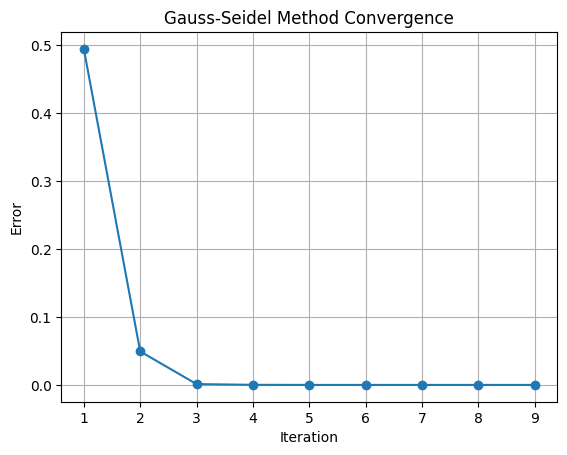

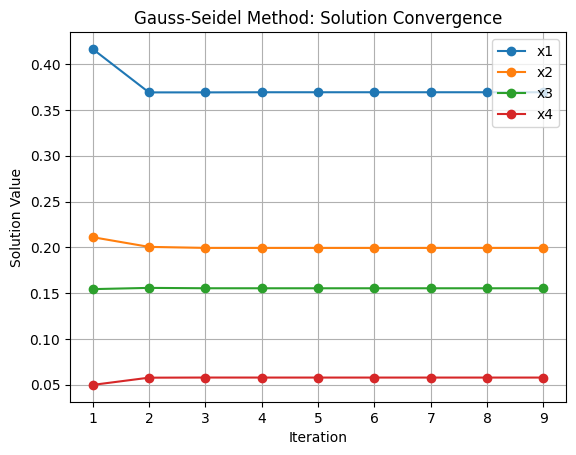

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def diagonally_dominant(A):
    n = len(A)
    for i in range(n):
        diagonal = abs(A[i, i])
        sum_other_elements = 0
        for j in range(n):
            if j != i:
                sum_other_elements += abs(A[i, j])
        if diagonal <= sum_other_elements:
            return False
    return True
def gauss_seidel(A, b, x0, max_iter=100, tol=1e-10):
    n = len(b)
    x = x0.copy()
    errors = []
    solutions = []
    for iteration in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j]*x[j]
            if A[i, i] == 0:
                raise ValueError("The diagonal element is zero.")
            x[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x - x_old)
        errors.append(error)
        solutions.append(x.copy())
        print("Iteration:", iteration + 1)
        print("x =", x)
        print("Error =", error)
        print()
        if error < tol:
            return x, iteration + 1, errors, solutions
    return x, max_iter, errors, solutions
A = np.array([
    [12,1,2,1],
    [2,15,1,2],
    [1,2,14,1],
    [2,1,2,13]], dtype=float)
b = np.array([5, 4, 3,2], dtype=float)
x0 = np.array([0, 0, 0,0], dtype=float)
print("Diagonal Dominance Check:")
if diagonally_dominant(A):
    print("Matrix is strictly diagonally dominant.")
else:
    print("Matrix is not strictly diagonally dominant.")
x, iterations, errors, solutions = gauss_seidel(A, b, x0)
print("Final Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iterations)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)

residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)

solutions = np.array(solutions)
print("\nIteration History:")
print("\nErrors:")
print(errors)

print("\nSolutions:")
print(solutions)
# Error vs Iteration Graph
plt.figure()
plt.plot(range(1, len(errors) + 1),errors,marker='o')
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Gauss-Seidel Method Convergence")
plt.grid()
plt.show()
# Solution Values vs Iteration
plt.figure()
plt.plot(range(1, len(solutions) + 1),solutions[:, 0],marker='o',label='x1')
plt.plot(range(1, len(solutions) + 1),solutions[:, 1],marker='o',label='x2')
plt.plot(range(1, len(solutions) + 1),solutions[:, 2],marker='o',label='x3')
plt.plot(range(1, len(solutions) + 1),solutions[:, 3],marker='o',label='x4')
plt.xlabel("Iteration")
plt.ylabel("Solution Value")
plt.title("Gauss-Seidel Method: Solution Convergence")
plt.legend()
plt.grid()
plt.show()

##**Comparison of Gauss-Seidel method and NumPy Solution:**
###**Question no 04:**

Write a Python program using NumPy to solve a system of five linear formulas by an iterative Gauss-Seidel method. The program should check for zero diagonal elements, start with an initial guess of , iterate to update the solution until the specified tolerance is achieved or the maximum number of iterations is reached, and display the solution, number of iterations, and residual error. Finally solve the same system with ⁣, calculate the residual error and compare the Gauss-Seidel solution with the NumPy solution by calculating the difference of the two solution vectors.Comparison of Gauss-Seidel method and NumPy Solution.Finally, solve the same system using ⁣, determine its residual error, and compare the Gauss-Seidel solution to the NumPy solution by calculating the difference between the two solution vectors.



In [ ]:
import numpy as np
def gauss_seidel(A, b, x0, max_iter=100, tol=1e-10):
    n = len(b)
    x = x0.copy()
    for i in range(n):
        if A[i, i] == 0:
            raise ValueError("The diagonal element is zero")
    for iteration in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j] * x[j]
            x[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x - x_old)
        print("Iteration:", iteration + 1)
        print("x =", x)
        print("Error =", error)
        print()
        if error < tol:
            return x, iteration + 1
    return x, max_iter

A = np.array([
    [19,2,3,4,1],
    [2,17,4,5,3],
    [1,2,21,3,2],
    [1,2,4,34,5],
    [5,4,6,2,76]],dtype=float)
b = np.array([2,1,3,4,1], dtype=float)
x0 = np.array([0,0,0,0,0], dtype=float)
x, iteration = gauss_seidel(A, b, x0)
print("\nGauss-Seidel Result")
print("\nFinal Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iteration)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)
x_numpy = np.linalg.solve(A, b)
print("\nSolution using NumPy:")
print("x =", x_numpy)
# Difference between Gauss-Seidel and NumPy

comparison_error = np.linalg.norm(x - x_numpy)
print("\nDifference between Gauss-Seidel and NumPy:")
print(comparison_error)
# Residual Error using NumPy

residual_numpy = np.linalg.norm(A @ x_numpy - b)
print("\nResidual Error using NumPy:")
print(residual_numpy)

Iteration: 1
x = [ 0.10526316  0.04643963  0.13342179  0.09612266 -0.00927435]
Error = 0.20090775167965283

Iteration: 2
x = [ 0.05955995 -0.00621161  0.127764    0.1025935  -0.00322006]
Error = 0.07050866939736146

Iteration: 3
x = [ 0.06431459 -0.00841132  0.12624608  0.10187129 -0.00327825]
Error = 0.00550221947256684

Iteration: 4
x = [ 0.06494092 -0.00790517  0.12627676  0.10182805 -0.00334738]
Error = 0.0008099800332540919

Iteration: 5
x = [ 0.06489554 -0.00788213  0.12628949  0.1018367  -0.00334684]
Error = 5.3172504670897274e-05

Iteration: 6
x = [ 0.06488925 -0.00788703  0.12628897  0.10183715 -0.00334614]
Error = 8.025970851461612e-06

Iteration: 7
x = [ 0.06488972 -0.00788722  0.12628883  0.10183706 -0.00334614]
Error = 5.277969695055864e-07

Iteration: 8
x = [ 0.06488978 -0.00788716  0.12628884  0.10183706 -0.00334615]
Error = 8.080355911314202e-08

Iteration: 9
x = [ 0.06488978 -0.00788716  0.12628884  0.10183706 -0.00334615]
Error = 5.674411910736629e-09

Iteration: 10
x

##**Comparison between Guass Jacobi and Guass Seidel Implementation:**

###**Question no 05:**

Write a Python program for solving a system of equations that are linear using the iterative Jacobi and Gauss-Seidel methods . Analyze the convergence of the Jacobi and the Gauss-Seidel methods by keeping track of the errors in the iterations . Compare the solutions and residual errors with the direct solution from ⁣ . Calculate differences between all solutions . Determine which iterative method converges faster . Plot the convergence behavior of the Jacobi and the Gauss-Seidel methods in a logarithmic error plot .


Jacobi Solution:
[ 0.06488977 -0.00788716  0.12628884  0.10183706 -0.00334615]

Gauss-Seidel Solution:
[ 0.06488977 -0.00788716  0.12628884  0.10183706 -0.00334615]

NumPy Solution:
[ 0.06488977 -0.00788716  0.12628884  0.10183706 -0.00334615]

Iterations:
Jacobi       : 27
Gauss-Seidel : 11

 Residual Error:
Jacobi       : 4.991771633605654e-10
Gauss-Seidel : 1.6035421908672255e-10
NumPy        : 2.220446049250313e-16
Difference from NumPy Solution
Jacobi       : 1.2732866073395196e-11
Gauss-Seidel : 7.931363520042458e-12
1.9788191545125278e-11

Comparison
Gauss-Seidel converged in fewer iterations.


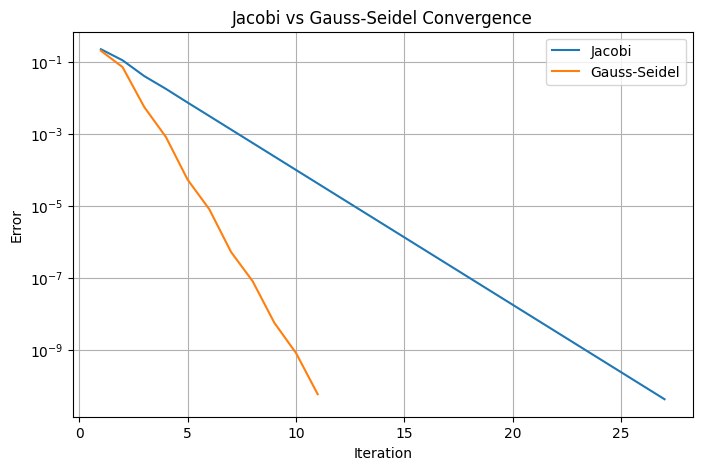

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, x0, max_iter=100, tol=1e-10):
    n = len(b)
    x = x0.copy()
    errors = []
    for i in range(n):
        if A[i, i] == 0:
            raise ValueError("The diagonal element is zero")
    for iteration in range(max_iter):
        x_new = np.zeros(n)
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j] * x[j]
            x_new[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x_new - x)
        errors.append(error)
        x = x_new
        if error < tol:
            return x, iteration + 1, errors
    return x, max_iter, errors

def gauss_seidel(A, b, x0, max_iter=100, tol=1e-10):
    n = len(b)
    x = x0.copy()
    errors = []
    for i in range(n):
        if A[i, i] == 0:
            raise ValueError("The diagonal element is zero")
    for iteration in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j] * x[j]
            x[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x - x_old)
        errors.append(error)
        if error < tol:
            return x, iteration + 1, errors
    return x, max_iter, error

A = np.array([
    [19, 2, 3, 4, 1],
    [2, 17, 4, 5, 3],
    [1, 2, 21, 3, 2],
    [1, 2, 4, 34, 5],
    [5, 4, 6, 2, 76]], dtype=float)
b = np.array([2, 1, 3, 4, 1], dtype=float)
x0 = np.array([0, 0, 0, 0, 0], dtype=float)

x_jacobi, iterations_jacobi, errors_jacobi = jacobi(A, b, x0)
x_seidel, iterations_seidel, errors_seidel = gauss_seidel(A, b, x0)

# NumPy Solution
x_numpy = np.linalg.solve(A, b)

residual_jacobi = np.linalg.norm(A @ x_jacobi - b)

residual_seidel = np.linalg.norm(A @ x_seidel - b)

residual_numpy = np.linalg.norm(A @ x_numpy - b)



difference_jacobi = np.linalg.norm(x_jacobi - x_numpy)

difference_seidel = np.linalg.norm(x_seidel - x_numpy)

difference_methods = np.linalg.norm(x_jacobi - x_seidel)


print("\nJacobi Solution:")
print(x_jacobi)

print("\nGauss-Seidel Solution:")
print(x_seidel)

print("\nNumPy Solution:")
print(x_numpy)

print("\nIterations:")
print("Jacobi       :", iterations_jacobi)
print("Gauss-Seidel :", iterations_seidel)

print("\n Residual Error:")
print("Jacobi       :", residual_jacobi)
print("Gauss-Seidel :", residual_seidel)
print("NumPy        :", residual_numpy)

print("Difference from NumPy Solution")
print("Jacobi       :", difference_jacobi)
print("Gauss-Seidel :", difference_seidel)
print(difference_methods)

print("\nComparison")
if iterations_jacobi < iterations_seidel:
    print("Jacobi converged in fewer iterations.")

elif iterations_seidel < iterations_jacobi:
    print("Gauss-Seidel converged in fewer iterations.")

else:
    print("Both methods used the same number of iterations.")
# Convergence Graph
plt.figure(figsize=(8, 5))
plt.plot( range(1, len(errors_jacobi) + 1), errors_jacobi, label="Jacobi")
plt.plot(range(1, len(errors_seidel) + 1),errors_seidel,label="Gauss-Seidel")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Jacobi vs Gauss-Seidel Convergence")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()